#Import Libraries

In [1]:
!pip install -U "ray[data,train,tune,serve]"

INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 143.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.8/456.8 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.7/517.7 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/

In [2]:
!pip install timm --quiet

In [44]:
# Standard library
import random
import os
import json
from functools import partial
from collections import OrderedDict
from typing import Any, Callable, NamedTuple, Optional
from datetime import datetime
import tempfile
from pathlib import Path
import math
import zipfile
import glob
import gc
from sklearn.model_selection import StratifiedKFold
from collections import defaultdict

# Third-party libraries
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

from sklearn.metrics import confusion_matrix
import torchvision
from torchvision import transforms
from torchvision.ops.misc import MLP

import timm
from tqdm import tqdm

from ray import tune, train
from ray.train import Checkpoint
from ray.tune import get_checkpoint
from ray.tune.schedulers import ASHAScheduler
import ray.cloudpickle as pickle

from transformers import AutoModelForImageClassification
from sklearn.model_selection import train_test_split

from google.colab import userdata
from google.colab import files

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
def send_to_gpu(*vars):
    # Sends all provided variables to GPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        moved = [v.to(device) for v in vars]
        return moved[0] if len(moved) == 1 else moved
    else:
        raise Exception("CUDA not available")

In [5]:
def set_seed(seed):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Load Data

In [6]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY'] = userdata.get('key')
os.environ['RAY_PICKLE_VERBOSE_DEBUG'] = '1'

!kaggle competitions download -c ecse-551-assignment-2-image-classification > /dev/null 2>&1
!unzip ecse-551-assignment-2-image-classification.zip > /dev/null 2>&1

!rm ecse-551-assignment-2-image-classification.zip

print("Downloaded and extracted dataset.")

Downloaded and extracted dataset.


## ImageDataset

In [7]:
class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

        # reset indices for get_item
        self.df = df.reset_index(drop=True)

        if not self.is_test:
            self.labels = df['label'].astype(str)
            # indexing with unique image names
            self.classes = sorted(self.labels.unique().tolist())
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        else:
            self.labels = None
            self.classes = None
            self.class_to_idx = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]  # filename
        img_path = os.path.abspath(os.path.join(self.img_dir, img_name))
        image = Image.open(img_path).convert('RGB')

        # Applying our sequence of transformations defined prev before returning the image (pseudo func prog)
        if self.transform:
          image = self.transform(image)

        if self.is_test:
            return image, img_name

        label = self.df.iloc[idx, 1]     # class name
        label_idx = self.class_to_idx[label]
        return image, label_idx

In [8]:
img_dir='kaggle_challenge/train'
labels_csv_file='kaggle_challenge/train_labels.csv'
labels_df = pd.read_csv(labels_csv_file)
num_classes = labels_df['label'].nunique()

# Task 2

## Training Utilities

In [9]:
class HFtoTimm(nn.Module):
    def __init__(self, checkpoint, num_classes=10):
        super().__init__()
        self.model = AutoModelForImageClassification.from_pretrained(checkpoint) # Loads fine-tuned Arch, weights, config...
        in_features = self.model.classifier.in_features
        self.model.classifier = nn.Linear(in_features, num_classes) # Change last layer

    def forward(self, x):
        return self.model(pixel_values=x).logits # Extracting logits (what we need in our avg) + HF excepts pixel_values arg

In [10]:
def validate_and_get_preds(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Validation', leave=False):
            inputs, labels = send_to_gpu(inputs, labels)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            # Collect data for per-class metrics
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    overall_acc = 100. * correct / total

    # Return the full set of true labels and predictions for aggregation
    return avg_loss, overall_acc, all_labels, all_preds

In [11]:
def adjust_learning_rate(optimizer, step, config):
    # Optional LR schedule: only apply if decay steps are defined
    decay_steps = config.get('lr_decay_steps', None)
    decay_factor = config.get('lr_decay_factor', None)

    if decay_steps is None or decay_factor is None:
        return  # no LR schedule defined for this config

    if step in decay_steps:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= decay_factor
            print(f"Step {step}: decayed LR to {param_group['lr']:.6f}")

In [12]:
def train_epoch(model, loader, criterion, optimizer, step_counter, config):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f'Training')
    for inputs, labels in pbar:
        if step_counter[0] >= config['total_steps']:
            break

        inputs, labels = send_to_gpu(inputs, labels)

        # Adjust LR if needed
        adjust_learning_rate(optimizer, step_counter[0], config)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        step_counter[0] += 1

        pbar.set_postfix({'loss': running_loss/(pbar.n+1),
                         'acc': 100.*correct/total,
                         'step': step_counter[0]})

    return running_loss / len(loader), 100. * correct / total

In [35]:
def train_single_seed(seed, train_loader, val_loader, config):
    print(f"\n{'='*40}")
    print(f"Training {config['model_name']} | Seed {seed}")
    print(f"LR: {config['lr']} | Batch: {config['batch_size']}")
    print(f"{'='*40}")

    set_seed(seed)

    if 'convnext' in config['model_name']:
        dpr = config.get('drop_path_rate', 0.0)
        model = timm.create_model(
            config['model_name'],
            pretrained=True,
            num_classes=10,
            drop_path_rate=dpr
        )

    elif 'resnet' in config['model_name'] or 'bit' in config['model_name']:
        model = timm.create_model(
            config['model_name'],
            pretrained=True,
            num_classes=10
        )

    elif "swin_hf_cifar10" in config['model_name']:
        model = HFtoTimm(
            checkpoint=config["hf_checkpoint"],
            num_classes=10
        )

    model = send_to_gpu(model)

    # Optimizer Creation
    opt_name = config.get('optimizer', 'SGD') # Default to SGD if missing

    if opt_name == 'AdamW':
        print(f"--> Using AdamW (LR: {config['lr']}, WD: {config['weight_decay']})")
        optimizer = optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    elif opt_name == 'SGD':
        # BiT uses Momentum=0.9 and 0 weight decay for transfer
        wd = config.get('weight_decay', 0.0)
        print(f"--> Using SGD (LR: {config['lr']}, Momentum: 0.9, WD: {wd})")
        optimizer = optim.SGD(
            model.parameters(),
            lr=config['lr'],
            momentum=0.9,
            weight_decay=wd
        )

    else:
        raise ValueError(f"Optimizer {opt_name} not supported in this function.")

    # Training
    criterion = nn.CrossEntropyLoss()

    step_counter = [0]
    best_val_acc = 0
    best_model_path = None

    # Lists to store the best performing predictions/labels for this fold
    best_fold_labels = []
    best_fold_preds = []

    # Standard loop calling prev helper
    while step_counter[0] < config['total_steps']:
        train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                           optimizer, step_counter, config)
        val_loss, val_acc, current_labels, current_preds = validate_and_get_preds(model, val_loader, criterion)

        print(f"Step {step_counter[0]}/{config['total_steps']} | "
              f"Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        if val_acc > best_val_acc: # Saving best model
            best_val_acc = val_acc

            # Store the best performing predictions/labels for this fold
            best_fold_labels = current_labels
            best_fold_preds = current_preds


            save_name = f"{config['short_name']}_seed{seed}.pth"
            torch.save(model.state_dict(), save_name)
            best_model_path = save_name

        if step_counter[0] >= config['total_steps']:
            break

    if best_model_path: # Returning best model
        print(f"Loading best model from {best_model_path}...")
        model.load_state_dict(torch.load(best_model_path))

    # Return overall accuracy AND the labels/predictions for aggregation
    return best_val_acc, best_fold_labels, best_fold_preds

In [14]:
def run_hpo_kfold(
    hpo_configs,
    labels_df,
    img_dir,
    train_transform,
    val_transform,
    train_func,
    dataset_cls,
    n_splits=2,
    seed_base=42
):
    # Initialize K-Fold (Stratified for class balance)
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed_base)

    hpo_results = []

    for idx, config in enumerate(hpo_configs):
        print(f"\n{'='*80}")
        print(f"HPO Config {idx+1}/{len(hpo_configs)} | Model: {config.get('model_name')}")
        param_str = ", ".join([f"{k}: {v}" for k, v in config.items()
                               if k not in ['model_name', 'short_name'] and isinstance(v, (int, float, str))])
        print(f"Params: {param_str}")
        print(f"{'='*80}")

        fold_scores = [] # Fold scores of a config

        X = labels_df.index.values
        y = labels_df['label'].values

        # CROSS VALIDATION LOOP
        for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
            print(f"  [Fold {fold+1}/{n_splits}] Preparing data...", end="")

            # Inject fold name into config so trainer saves unique files
            # e.g. "BiT_lr0.003_seed42_fold0.pth"
            config['current_fold'] = fold

            # Split Data
            train_fold_df = labels_df.iloc[train_idx].reset_index(drop=True)
            val_fold_df = labels_df.iloc[val_idx].reset_index(drop=True)

            # Create Datasets
            t_trans = config.get('train_transform', train_transform)
            v_trans = config.get('val_transform', val_transform)
            train_dataset = dataset_cls(train_fold_df, img_dir, transform=t_trans)
            val_dataset = dataset_cls(val_fold_df, img_dir, transform=v_trans)

            # Create Loaders
            train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                                     shuffle=True, num_workers=2, pin_memory=True)
            val_loader = DataLoader(val_dataset, batch_size=config['batch_size'],
                                   shuffle=False, num_workers=2, pin_memory=True)

            print(f" Training...")
            best_acc, model = train_func(seed_base, train_loader, val_loader, config)
            fold_scores.append(best_acc)

            # MEMORY CLEANUP for GPU OOM
            del model, train_loader, val_loader, train_dataset, val_dataset
            torch.cuda.empty_cache()
            gc.collect()

        # AGGREGATE RESULTS for a full config run
        mean_acc = np.mean(fold_scores)
        std_acc = np.std(fold_scores)

        result_entry = {
            'config': config.copy(),
            'mean_val_acc': mean_acc,
            'std_val_acc': std_acc,
            'fold_scores': fold_scores
        }
        hpo_results.append(result_entry)

        print(f"\n>>> Config Result: {mean_acc:.2f}% ± {std_acc:.2f}%")
        print(f"    Scores: {[round(x, 2) for x in fold_scores]}")

    # Final summary
    if not hpo_results:
        return None, []

    best_result = max(hpo_results, key=lambda x: x['mean_val_acc'])
    print(f"\n{'#'*80}")
    print(f"BEST CONFIG FOUND: {best_result['config'].get('model_name', 'Unknown')}")
    print(f"Mean Accuracy: {best_result['mean_val_acc']:.2f}%")
    print(f"{'#'*80}")

    return best_result, hpo_results

In [42]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def run_production_5fold(base_config, labels_df, img_dir, dataset_cls, n_folds=5, base_seed=42, class_names=class_names):
    # Saves fold-specific models but doesn't run diff HP configs

    # Prepare the Stratified Folds
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=base_seed)
    fold_splits = list(skf.split(labels_df.index, labels_df['label']))

    model_name = base_config['model_name']
    print(f"\n{'='*60}")
    print(f"STARTING 5-FOLD TRAINING FOR: {model_name}")
    print(f"Config: {base_config['short_name']}")
    print(f"{'='*60}")

    fold_scores = []
    all_class_accs = defaultdict(list)

    for fold, (train_idx, val_idx) in enumerate(fold_splits):
        print(f"\n--- Fold {fold+1}/{n_folds} ---")

        # Create Fold-Specific Config
        # We modify the 'short_name' so train_single_seed saves it with a unique name for the fold num
        fold_config = base_config.copy() # Only 1 config... ran on multiple folds
        fold_config['short_name'] = f"{base_config['short_name']}_Fold{fold}"

        # Split Data
        train_sub = labels_df.iloc[train_idx].reset_index(drop=True)
        val_sub   = labels_df.iloc[val_idx].reset_index(drop=True)

        # Setup Dataset and Loaders
        train_ds = dataset_cls(train_sub, img_dir, transform=fold_config['train_transform'])
        val_ds   = dataset_cls(val_sub,   img_dir, transform=fold_config['val_transform'])

        train_loader = DataLoader(train_ds, batch_size=fold_config['batch_size'],
                                  shuffle=True, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=fold_config['batch_size'],
                                  shuffle=False, num_workers=2, pin_memory=True)


        best_acc, fold_labels, fold_preds = train_single_seed(base_seed, train_loader, val_loader, fold_config)
        fold_scores.append(best_acc)

        cm = confusion_matrix(fold_labels, fold_preds) # Per class accuracies
        # Use try/except for perfect prediction case where cm.sum(axis=1) might have zeros
        try:
            # Per-Class Accuracy = (True Positives) / (Total for that class in validation set)
            fold_class_accs = cm.diagonal()/cm.sum(axis=1)
        except:
            # Fallback if a class had zero samples (shouldn't happen with StratifiedKFold unless n_splits > num_samples for any class)
            fold_class_accs = [1.0] * len(class_names)

        # Store the scores
        for i, acc in enumerate(fold_class_accs):
            all_class_accs[class_names[i]].append(acc * 100)

        print(f"--> Fold {fold+1} Finished. Best Acc: {best_acc:.2f}%")
        print(f"--> Saved as: {fold_config['short_name']}_seed{base_seed}.pth")

        # Garbage Collection to free GPU for next fold
        del train_loader, val_loader, train_ds, val_ds
        torch.cuda.empty_cache()
        gc.collect()

    final_results = {'overall_mean_acc': np.mean(fold_scores), 'overall_std_acc': np.std(fold_scores)}
    print(f"\n{'#'*80}")
    print(f"FINAL PER-CLASS CV RESULTS ({model_name})")
    print(f"{'#'*80}")
    print(f"Overall Mean Accuracy: {final_results['overall_mean_acc']:.4f}% ± {final_results['overall_std_acc']:.4f}%\n")

    # Calculate mean and std for each class
    print(f"{'Class':<10} | {'Mean Acc':<10} | {'Std Dev':<10}")
    print("-" * 35)
    for cls_name in class_names:
        mean = np.mean(all_class_accs[cls_name])
        std = np.std(all_class_accs[cls_name])
        final_results[cls_name] = {'mean': mean, 'std': std}
        print(f"{cls_name:<10} | {mean:.4f}% | ±{std:.4f}%")

    print(f"\n{'='*80}\n")
    return final_results, all_class_accs

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_cv_class_accuracies(all_class_accs, short_name):
    # 1. Convert dictionary of lists into a DataFrame
    df = pd.DataFrame(all_class_accs)

    # 2. Melt the DataFrame to 'long' format
    df_melt = df.melt(var_name='Class', value_name='Accuracy (%)')

    plt.figure(figsize=(10, 6))

    # 3. Create the Box Plot (showing distribution) and Strip Plot (showing individual points)
    sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)
    sns.stripplot(x='Class', y='Accuracy (%)', data=df_melt, color='black', size=4, jitter=True)

    plt.title(f'5-Fold Cross-Validation Accuracy per Class\nModel: {short_name}', fontsize=14)
    plt.xlabel('Class Name', fontsize=12)
    plt.ylabel('Fold Accuracy (%)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # --- CRITICAL MODIFICATION: Cropping the Y-axis ---
    plt.ylim(85, 100) # Set the y-axis to focus on 85% to 100%

    plt.tight_layout()

    # Save the plot
    plot_filename = f"cv_results_{short_name}.png"
    plt.savefig(plot_filename)
    print(f"\n✅ Plot saved as: {plot_filename}")
    plt.show()

## Instantiation and Configuration

In [17]:
# Downstream Diversity
SEEDS = [42, 123, 456, 789, 2024]

# Upstream Diversity
target_models = [
    "resnetv2_50x1_bit.goog_in21k",  # BiT-M
    "convnext_tiny.fb_in22k",        # ConvNeXt
    "swin_tiny_patch4_window7_224",   # Swin-Tiny (ViT-style)
]

print(f"{'='*50}")
print(f"Downloading and Verifying {len(target_models)} Models...")
print(f"{'='*50}\n")

for model_name in target_models:
    try:
        print(f"Downloading {model_name}...")

        # triggers download
        model = timm.create_model(model_name, pretrained=True, num_classes=10)

        print(f"Successfully loaded {model_name}")
        del model
        torch.cuda.empty_cache()

    except Exception as e:
        raise Exception(f"FAILED to load {model_name}, {str(e)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/273M [00:00<?, ?B/s]

Successfully loaded resnetv2_50x1_bit.goog_in21k


model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

Successfully loaded convnext_tiny.fb_in22k


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Successfully loaded swin_tiny_patch4_window7_224


# HPO

### BiT

In [28]:
bit_train_transform = transforms.Compose([
    transforms.Resize(160),  # Resize smaller dimension to 160
    transforms.RandomCrop(128),  # Random crop 128x128
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

bit_val_transform = transforms.Compose([
    transforms.Resize(128),  # Resize to 128x128 for validation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


target_pairs = [
    (500, 512),   # Baseline: 256k images seen
    (2000, 128),  # Same budget (256k images), but smaller batch/more updates
    (1000, 512),  # Double budget (512k images)
]

hpo_configs = []

for steps, batch_size in target_pairs:
    # BiT-HyperRule: Decay LR at 30%, 60%, 90% of total steps
    decay_steps = [int(steps * 0.3), int(steps * 0.6), int(steps * 0.9)]

    config = {
        'model_name': 'resnetv2_50x1_bit.goog_in21k',
        'short_name': f'BiT_bs{batch_size}_steps{steps}',
        'lr': 0.003,              # Standard BiT rule
        'momentum': 0.9,          # Standard BiT rule
        'weight_decay': 0,
        'batch_size': batch_size,
        'total_steps': steps,
        'lr_decay_steps': decay_steps,
        'lr_decay_factor': 0.1
    }
    hpo_configs.append(config)

print(f"Generated {len(hpo_configs)} configurations.")
for c in hpo_configs:
    print(f"• {c['short_name']}: LR={c['lr']}, Decay at {c['lr_decay_steps']}")

Generated 3 configurations.
• BiT_bs512_steps500: LR=0.003, Decay at [150, 300, 450]
• BiT_bs128_steps2000: LR=0.003, Decay at [600, 1200, 1800]
• BiT_bs512_steps1000: LR=0.003, Decay at [300, 600, 900]


In [ ]:
best_config, all_results = run_hpo_kfold(
    hpo_configs,
    labels_df,
    img_dir,
    bit_train_transform,
    bit_val_transform,
    train_single_seed,
    ImageDataset
)

#### Saving Config

In [ ]:
import pickle
import os

# Save the metrics dictionary to disk
with open('hpo_results_backup_CNN.pkl', 'wb') as f:
    pickle.dump(all_results, f)

print("Results saved")

Results saved


In [ ]:
import pickle
import numpy as np

# 1. Load the results from disk
file_path = 'hpo_results_backup_CNN.pkl'

try:
    with open(file_path, 'rb') as f:
        loaded_results = pickle.load(f)
    print(f"Successfully loaded {len(loaded_results)} configurations.\n")

    # 2. Print details for each config
    print(f"{'ID':<4} | {'Batch':<6} | {'Steps':<6} | {'Mean Acc':<10} | {'Std Dev':<10}")
    print("-" * 55)

    for idx, res in enumerate(loaded_results):
        cfg = res['config']
        mean = res['mean_val_acc']
        std = res['std_val_acc']

        print(f"{idx+1:<4} | {cfg['batch_size']:<6} | {cfg['total_steps']:<6} | "
              f"{mean:.2f}%     | ±{std:.2f}%")

    # 3. Identify and print the winner
    best_result = max(loaded_results, key=lambda x: x['mean_val_acc'])
    print("\n" + "="*40)
    print("WINNING CONFIGURATION")
    print("="*40)
    print(f"Batch Size:  {best_result['config']['batch_size']}")
    print(f"Total Steps: {best_result['config']['total_steps']}")
    print(f"Accuracy:    {best_result['mean_val_acc']:.4f}%")

except FileNotFoundError:
    print(f"Error: Could not find '{file_path}'. Make sure you uploaded the file.")

Successfully loaded 3 configurations.

ID   | Batch  | Steps  | Mean Acc   | Std Dev   
-------------------------------------------------------
1    | 512    | 500    | 95.36%     | ±0.41%
2    | 128    | 2000   | 94.49%     | ±0.31%
3    | 512    | 1000   | 95.57%     | ±0.32%

WINNING CONFIGURATION
Batch Size:  512
Total Steps: 1000
Accuracy:    95.5700%


In [ ]:
from google.colab import files
files.download('hpo_results_backup.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ConvNextNet

In [29]:
# ConvNeXt requires 224x224 for pretrained weights to work well
cnx_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize 32 -> 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Light augmentation --> paper mentionned translation equivariance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Standard ImageNet norms
                         std=[0.229, 0.224, 0.225])
])

cnx_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

cnx_hpo_configs = []

# Fix parameters that are part of the cnx paper (Table 5 in paper)
optimizer = 'AdamW'
label_smoothing = 0.0 # Maybe test w 0.1?

learning_rates = [1e-4, 5e-5] # Fine-tuning requires lower LR than pre-training (4e-3)
weight_decays = [0.01, 0.03]  # 0.05 is paper default --> smaller LR safer for smaller data
drop_path_rates = [0.1, 0.2]  # Paper uses 0.1 for Tiny models

for lr in learning_rates:
    for wd in weight_decays:
        for dpr in drop_path_rates:
            config = {
                'model_name': 'convnext_tiny.fb_in22k',
                'short_name': f'CNX_lr{lr}_wd{wd}_dpr{dpr}',

                # Fixed constraints
                'batch_size': 64,
                'total_steps': 1000,
                'optimizer': optimizer,
                'label_smoothing': label_smoothing,

                # Search parameters
                'lr': lr,
                'weight_decay': wd,
                'drop_path_rate': dpr, # they mentionned close training to ViT is preferrable

                'train_transform': cnx_train_transform,
                'val_transform': cnx_val_transform
            }
            cnx_hpo_configs.append(config)

In [ ]:
best_cnx_config, cnx_results = run_hpo_kfold(
    hpo_configs=cnx_hpo_configs,
    labels_df=labels_df,
    img_dir=img_dir,
    train_transform=None,
    val_transform=None,
    train_func=train_single_seed,
    dataset_cls=ImageDataset
)

# 3. Print Final Winner
print(f"\nWinner: {best_cnx_config['config']['short_name']}")
print(f"Acc: {best_cnx_config['mean_val_acc']:.2f}%")

#### Saving config

In [ ]:
import pickle
import os

# Save the metrics dictionary to disk
with open('hpo_results_backup_CNX.pkl', 'wb') as f:
    pickle.dump(cnx_results, f)

print("Results saved")

Results saved


In [ ]:
import pickle
import numpy as np

# 1. Load the results from disk
file_path = 'hpo_results_backup_CNX.pkl'

try:
    with open(file_path, 'rb') as f:
        loaded_results = pickle.load(f)
    print(f"Successfully loaded {len(loaded_results)} configurations.\n")

    # 2. Print details for each config
    header = (
        f"{'ID':<3} | {'Short Name':<18} | {'LR':<9} | {'WD':<6} | "
        f"{'DPR':<5} | {'Batch':<5} | {'Steps':<6} | {'Mean Acc':<9} | {'Std Dev':<8}"
    )
    print(header)
    print("-" * len(header))

    for idx, res in enumerate(loaded_results):
        cfg  = res['config']
        mean = res['mean_val_acc']
        std  = res['std_val_acc']

        short_name    = cfg.get('short_name', cfg.get('model_name', 'N/A'))
        lr            = cfg.get('lr', float('nan'))
        weight_decay  = cfg.get('weight_decay', float('nan'))
        drop_path     = cfg.get('drop_path_rate', float('nan'))
        batch_size    = cfg.get('batch_size', 'N/A')
        total_steps   = cfg.get('total_steps', 'N/A')

        # Assuming mean/std are already in percent (e.g. 83.42 for 83.42%)
        print(
            f"{idx+1:<3} | "
            f"{short_name:<18} | "
            f"{lr:<9.1e} | "
            f"{weight_decay:<6.3f} | "
            f"{drop_path:<5.2f} | "
            f"{batch_size:<5} | "
            f"{total_steps:<6} | "
            f"{mean:>7.2f}% | "
            f"±{std:>6.2f}%"
        )

    # 3. Identify and print the winner
    best_result = max(loaded_results, key=lambda x: x['mean_val_acc'])
    best_cfg    = best_result['config']

    print("\n" + "=" * 40)
    print("WINNING CONFIGURATION")
    print("=" * 40)
    print(f"ID / Short Name: {best_cfg.get('short_name', best_cfg.get('model_name', 'N/A'))}")
    print(f"Model:          {best_cfg.get('model_name', 'N/A')}")
    print(f"Learning Rate:  {best_cfg.get('lr', float('nan')):.1e}")
    print(f"Weight Decay:   {best_cfg.get('weight_decay', float('nan')):.3f}")
    print(f"Drop Path:      {best_cfg.get('drop_path_rate', float('nan')):.2f}")
    print(f"Batch Size:     {best_cfg.get('batch_size', 'N/A')}")
    print(f"Total Steps:    {best_cfg.get('total_steps', 'N/A')}")
    print(f"Mean Accuracy:  {best_result['mean_val_acc']:.4f}%")
    print(f"Std Dev:        {best_result['std_val_acc']:.4f}%")

except FileNotFoundError:
    print(f"Error: Could not find '{file_path}'. Make sure you uploaded the file.")


Successfully loaded 8 configurations.

ID  | Short Name         | LR        | WD     | DPR   | Batch | Steps  | Mean Acc  | Std Dev 
---------------------------------------------------------------------------------------------
1   | CNX_lr0.0001_wd0.01_dpr0.1 | 1.0e-04   | 0.010  | 0.10  | 64    | 1000   |   96.47% | ±  0.07%
2   | CNX_lr0.0001_wd0.01_dpr0.2 | 1.0e-04   | 0.010  | 0.20  | 64    | 1000   |   96.27% | ±  0.15%
3   | CNX_lr0.0001_wd0.03_dpr0.1 | 1.0e-04   | 0.030  | 0.10  | 64    | 1000   |   96.63% | ±  0.03%
4   | CNX_lr0.0001_wd0.03_dpr0.2 | 1.0e-04   | 0.030  | 0.20  | 64    | 1000   |   96.20% | ±  0.16%
5   | CNX_lr5e-05_wd0.01_dpr0.1 | 5.0e-05   | 0.010  | 0.10  | 64    | 1000   |   96.67% | ±  0.01%
6   | CNX_lr5e-05_wd0.01_dpr0.2 | 5.0e-05   | 0.010  | 0.20  | 64    | 1000   |   96.37% | ±  0.11%
7   | CNX_lr5e-05_wd0.03_dpr0.1 | 5.0e-05   | 0.030  | 0.10  | 64    | 1000   |   96.65% | ±  0.03%
8   | CNX_lr5e-05_wd0.03_dpr0.2 | 5.0e-05   | 0.030  | 0.20  | 64    

In [ ]:
from google.colab import files
files.download('hpo_results_backup_CNX.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ViT

In [31]:
def make_swin_transform(img_size):
    """Build individual train/val transforms for a given image size."""
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomCrop(img_size, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.25)
    ])

    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return train_tf, val_tf


raw_vit_configs = [
    {"lr": 5e-5, "weight_decay": 0.01, "drop_path_rate": 0.1, "img_size": 224},
    {"lr": 5e-5, "weight_decay": 0.01, "drop_path_rate": 0.2, "img_size": 224},
    {"lr": 5e-5, "weight_decay": 0.03, "drop_path_rate": 0.1, "img_size": 224},
    {"lr": 5e-5, "weight_decay": 0.03, "drop_path_rate": 0.2, "img_size": 224},
    {"lr": 2e-5, "weight_decay": 0.01, "drop_path_rate": 0.1, "img_size": 224},
    {"lr": 2e-5, "weight_decay": 0.03, "drop_path_rate": 0.2, "img_size": 224},
]

swin_hpo_configs = []

for idx, cfg in enumerate(raw_vit_configs, start=1):
    lr  = cfg["lr"]
    wd  = cfg["weight_decay"]
    dpr = cfg["drop_path_rate"]
    img = cfg["img_size"]

    # Build transforms
    train_tf, val_tf = make_swin_transform(img)

    config = {
        "model_name": "swin_hf_cifar10",
        "hf_checkpoint": "nielsr/swin-tiny-patch4-window7-224-finetuned-cifar10",
        "use_cifar10_init": True,

        "short_name": f"SWIN_cfg{idx}_lr{lr}_wd{wd}_dp{dpr}_img{img}",
        "batch_size": 64,
        "total_steps": 500,
        "optimizer": "AdamW",
        "label_smoothing": 0.0,

        # HPO params
        "lr": lr,
        "weight_decay": wd,
        "drop_path_rate": dpr,
        "img_size": img,
        "train_transform": train_tf,
        "val_transform": val_tf,
    }

    swin_hpo_configs.append(config)

print(f"Generated {len(swin_hpo_configs)} Swin-Tiny HPO configs:")
for c in swin_hpo_configs:
    print("•", c["short_name"])


Generated 6 Swin-Tiny HPO configs:
• SWIN_cfg1_lr5e-05_wd0.01_dp0.1_img224
• SWIN_cfg2_lr5e-05_wd0.01_dp0.2_img224
• SWIN_cfg3_lr5e-05_wd0.03_dp0.1_img224
• SWIN_cfg4_lr5e-05_wd0.03_dp0.2_img224
• SWIN_cfg5_lr2e-05_wd0.01_dp0.1_img224
• SWIN_cfg6_lr2e-05_wd0.03_dp0.2_img224


In [ ]:
best_swin_config, swin_results = run_hpo_kfold(
    hpo_configs=swin_hpo_configs,
    labels_df=labels_df,
    img_dir=img_dir,
    train_transform=None,          # We embedded transforms in each config
    val_transform=None,            # (run_hpo_kfold will fall back to config[...] )
    train_func=train_single_seed,
    dataset_cls=ImageDataset
)

print(f"\nWinner (Swin-Tiny): {best_swin_config['config']['short_name']}")
print(f"Acc: {best_swin_config['mean_val_acc']:.2f}%")



HPO Config 1/6 | Model: swin_hf_cifar10
Params: hf_checkpoint: nielsr/swin-tiny-patch4-window7-224-finetuned-cifar10, use_cifar10_init: True, batch_size: 64, total_steps: 500, optimizer: AdamW, label_smoothing: 0.1, lr: 5e-05, weight_decay: 0.01, drop_path_rate: 0.1, img_size: 224
  [Fold 1/2] Preparing data... Training...

Training swin_hf_cifar10 | Seed 42
LR: 5e-05 | Batch: 64
Loading HuggingFace Swin-Tiny CIFAR10 checkpoint...
--> Using AdamW (LR: 5e-05, WD: 0.01)


Training: 100%|██████████| 79/79 [00:16<00:00,  4.87it/s, loss=0.967, acc=67.6, step=79]


Step 79/500 | Train: 67.62% | Val: 90.66%


Training: 100%|██████████| 79/79 [00:15<00:00,  5.06it/s, loss=0.332, acc=88.4, step=158]


Step 158/500 | Train: 88.44% | Val: 93.66%


...

Step 395/500 | Train: 93.04% | Val: 94.48%


Training: 100%|██████████| 79/79 [00:15<00:00,  5.06it/s, loss=0.189, acc=93.9, step=474]


Step 474/500 | Train: 93.92% | Val: 94.88%


Training:  33%|███▎      | 26/79 [00:05<00:11,  4.59it/s, loss=0.172, acc=94.5, step=500]


Step 500/500 | Train: 94.47% | Val: 94.78%
Loading best model from SWIN_cfg6_lr2e-05_wd0.03_dp0.2_img224_seed42.pth...

>>> Config Result: 94.95% ± 0.07%
    Scores: [95.02, 94.88]

################################################################################
BEST CONFIG FOUND: swin_hf_cifar10
Mean Accuracy: 95.37%
################################################################################

Winner (Swin-Tiny): SWIN_cfg3_lr5e-05_wd0.03_dp0.1_img224
Acc: 95.37%


#### Saving Results

In [ ]:
import pickle
import os

# Save the metrics dictionary to disk
with open('hpo_results_backup_ViT.pkl', 'wb') as f:
    pickle.dump(swin_results, f)

print("Results saved")

Results saved


In [ ]:
import pickle
import numpy as np
import pandas as pd

# 1. Load the results
file_path = 'hpo_results_backup_ViT.pkl'

with open(file_path, 'rb') as f:
    loaded_results = pickle.load(f)

print(f"Loaded {len(loaded_results)} configurations.\n")

# 2. Create a structured table
data = []
for idx, res in enumerate(loaded_results):
    cfg = res['config']
    data.append({
        'ID': idx + 1,
        'LR': cfg.get('lr', float('nan')),
        'WD': cfg.get('weight_decay', float('nan')),
        'DropPath': cfg.get('drop_path_rate', float('nan')),
        'ImgSize': cfg.get('img_size', 'N/A'),
        'MeanAcc': res['mean_val_acc'],
        'StdAcc': res['std_val_acc'],
        'ShortName': cfg.get('short_name', 'N/A')
    })

df = pd.DataFrame(data)

# 3. Print full table sorted by accuracy
print("=" * 100)
print("ALL CONFIGURATIONS (Sorted by Mean Accuracy)")
print("=" * 100)
print(df.sort_values('MeanAcc', ascending=False).to_string(index=False))

# 4. Group Analysis
print("\n" + "=" * 100)
print("ANALYSIS BY LEARNING RATE GROUPS")
print("=" * 100)

for lr_group in [5e-5, 1e-4, 2e-5]:
    group_df = df[df['LR'] == lr_group]
    if not group_df.empty:
        print(f"\n📊 LR = {lr_group:.0e} Group (n={len(group_df)})")
        print(f"   Best:  {group_df['MeanAcc'].max():.2f}% (ID {group_df.loc[group_df['MeanAcc'].idxmax(), 'ID']:.0f})")
        print(f"   Mean:  {group_df['MeanAcc'].mean():.2f}%")
        print(f"   Worst: {group_df['MeanAcc'].min():.2f}% (ID {group_df.loc[group_df['MeanAcc'].idxmin(), 'ID']:.0f})")

# 5. Hyperparameter Effect Analysis
print("\n" + "=" * 100)
print("HYPERPARAMETER EFFECTS")
print("=" * 100)

print("\nWeight Decay Impact:")
for wd in df['WD'].unique():
    wd_df = df[df['WD'] == wd]
    print(f"   WD={wd:.2f}: Mean Acc = {wd_df['MeanAcc'].mean():.2f}% (n={len(wd_df)})")

print("\nDrop Path Rate Impact:")
for dp in sorted(df['DropPath'].unique()):
    dp_df = df[df['DropPath'] == dp]
    print(f"   DropPath={dp:.1f}: Mean Acc = {dp_df['MeanAcc'].mean():.2f}% (n={len(dp_df)})")

print("\nImage Size Impact:")
for img in sorted(df['ImgSize'].unique()):
    img_df = df[df['ImgSize'] == img]
    print(f"   ImgSize={img}: Mean Acc = {img_df['MeanAcc'].mean():.2f}% (n={len(img_df)})")  # Fixed: MgAcc → MeanAcc

# 6. Top 3 Configurations
print("\n" + "=" * 100)
print("TOP 3 CONFIGURATIONS")
print("=" * 100)

top3 = df.nlargest(3, 'MeanAcc')
for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"\n#{rank}: {row['ShortName']}")
    print(f"   LR={row['LR']:.0e}, WD={row['WD']:.2f}, DropPath={row['DropPath']:.1f}, ImgSize={row['ImgSize']}")
    print(f"   Accuracy: {row['MeanAcc']:.2f}% ± {row['StdAcc']:.2f}%")

# 7. Stability Analysis (Low variance = more reliable)
print("\n" + "=" * 100)
print("MOST STABLE CONFIGURATIONS (Low Std Dev)")
print("=" * 100)

stable = df.nsmallest(3, 'StdAcc')
for rank, (_, row) in enumerate(stable.iterrows(), 1):
    print(f"\n#{rank}: {row['ShortName']}")
    print(f"   Accuracy: {row['MeanAcc']:.2f}% ± {row['StdAcc']:.2f}%")

# 8. Winner Summary
best = df.loc[df['MeanAcc'].idxmax()]
print("\n" + "=" * 100)
print("WINNING CONFIGURATION")
print("=" * 100)
print(f"Config ID:      {best['ID']:.0f}")
print(f"Short Name:     {best['ShortName']}")
print(f"Learning Rate:  {best['LR']:.0e}")
print(f"Weight Decay:   {best['WD']:.3f}")
print(f"Drop Path:      {best['DropPath']:.2f}")
print(f"Image Size:     {best['ImgSize']}")
print(f"Mean Accuracy:  {best['MeanAcc']:.2f}%")
print(f"Std Deviation:  {best['StdAcc']:.2f}%")
print("=" * 100)

# 9. Key Insights
print("\nKEY INSIGHTS:")
print(f"• Accuracy Range: {df['MeanAcc'].min():.2f}% - {df['MeanAcc'].max():.2f}% (Δ={df['MeanAcc'].max()-df['MeanAcc'].min():.2f}%)")
print(f"• Best LR Group: {df.groupby('LR')['MeanAcc'].mean().idxmax():.0e}")
print(f"• Optimal Weight Decay: {df.groupby('WD')['MeanAcc'].mean().idxmax():.2f}")
print(f"• Optimal Drop Path: {df.groupby('DropPath')['MeanAcc'].mean().idxmax():.1f}")
print(f"• Optimal Image Size: {df.groupby('ImgSize')['MeanAcc'].mean().idxmax()}")

Loaded 6 configurations.

ALL CONFIGURATIONS (Sorted by Mean Accuracy)
 ID      LR   WD  DropPath  ImgSize  MeanAcc  StdAcc                             ShortName
  4 0.00005 0.03       0.2      224    95.37    0.01 SWIN_cfg4_lr5e-05_wd0.03_dp0.2_img224
  3 0.00005 0.03       0.1      224    95.37    0.01 SWIN_cfg3_lr5e-05_wd0.03_dp0.1_img224
  2 0.00005 0.01       0.2      224    95.25    0.01 SWIN_cfg2_lr5e-05_wd0.01_dp0.2_img224
  1 0.00005 0.01       0.1      224    95.25    0.01 SWIN_cfg1_lr5e-05_wd0.01_dp0.1_img224
  6 0.00002 0.03       0.2      224    94.95    0.07 SWIN_cfg6_lr2e-05_wd0.03_dp0.2_img224
  5 0.00002 0.01       0.1      224    94.91    0.09 SWIN_cfg5_lr2e-05_wd0.01_dp0.1_img224

ANALYSIS BY LEARNING RATE GROUPS

📊 LR = 5e-05 Group (n=4)
   Best:  95.37% (ID 3)
   Mean:  95.31%
   Worst: 95.25% (ID 1)

📊 LR = 2e-05 Group (n=2)
   Best:  94.95% (ID 6)
   Mean:  94.93%
   Worst: 94.91% (ID 5)

HYPERPARAMETER EFFECTS

🔬 Weight Decay Impact:
   WD=0.01: Mean Acc = 95.14

In [ ]:
from google.colab import files
files.download('hpo_results_backup_ViT.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Train + Save (individual models)

In [ ]:
# Train 3 archs × 5 CV = 15 models for ensemble
print(f"\n{'='*60}")
print("TRAINING 15 MODELS (3 CONFIGS × 5 SEEDS)")
print(f"{'='*60}")

# label smoothing is added but not applied in the interest of time... Maybe will do later
# Not used in the code, just kept here for centralized configs
configs_to_train = [
    {
        'model_name': 'convnext_tiny.fb_in22k',
        'short_name': 'CNX_Best_5Fold',
        'batch_size': 64,
        'total_steps': 1000,
        'optimizer': 'AdamW',
        'label_smoothing': 0.1,
        'lr': 5e-5,
        'weight_decay': 0.01,
        'drop_path_rate': 0.1,
        'transform_name': 'cnx_transform'
    },

    {
        'model_name': 'resnetv2_50x1_bit.goog_in21k',
        'short_name': 'BiT_Best_5Fold',
        'batch_size': 512,
        'total_steps': 1000,
        'optimizer': 'SGD',
        'momentum': 0.9,
        'lr': 0.003,
        'weight_decay': 0,
        'lr_decay_steps': [300, 600, 900], # Decay at 30%, 60%, 90% of 1000
        'transform_name': 'bit_transform'
    },

    {
        'model_name': 'swin_hf_cifar10',
        'hf_checkpoint': 'nielsr/swin-tiny-patch4-window7-224-finetuned-cifar10',
        'short_name': 'Swin_Best_5Fold',
        'batch_size': 64,
        'total_steps': 500,
        'optimizer': 'AdamW',
        'label_smoothing': 0.1,
        'lr': 5e-5,
        'weight_decay': 0.03,
        'drop_path_rate': 0.1,
        'img_size': 224,
        'use_cifar10_init': True,
        'transform_name': 'swin_transform'
    }
]

all_models = []
all_results = []

### BiT


STARTING 5-FOLD TRAINING FOR: resnetv2_50x1_bit.goog_in21k
Config: Ensemble_BiT

--- Fold 1/5 ---

Training resnetv2_50x1_bit.goog_in21k | Seed 42
LR: 0.003 | Batch: 512
--> Using SGD (LR: 0.003, Momentum: 0.9, WD: 0)


Training: 100%|██████████| 16/16 [00:05<00:00,  2.69it/s, loss=0.767, acc=75.3, step=16]


Step 16/1000 | Train: 75.34% | Val: 91.90%


Training: 100%|██████████| 16/16 [00:05<00:00,  2.76it/s, loss=0.3, acc=91.8, step=32]


Step 32/1000 | Train: 91.81% | Val: 90.45%


...

Step 992/1000 | Train: 99.95% | Val: 95.25%


Training:  50%|█████     | 8/16 [00:04<00:04,  1.92it/s, loss=0.00162, acc=100, step=1000]


Step 1000/1000 | Train: 100.00% | Val: 95.25%
Loading best model from Ensemble_BiT_Fold4_seed42.pth...
--> Fold 5 Finished. Best Acc: 95.75%
--> Saved as: Ensemble_BiT_Fold4_seed42.pth

################################################################################
FINAL PER-CLASS CV RESULTS (resnetv2_50x1_bit.goog_in21k)
################################################################################
Overall Mean Accuracy: 95.5700% ± 0.3203%

Class      | Mean Acc   | Std Dev   
-----------------------------------
airplane   | 97.0297% | ±1.1289%
automobile | 98.2609% | ±0.8423%
bird       | 95.5337% | ±0.9513%
cat        | 90.2835% | ±0.7407%
deer       | 95.8932% | ±1.4138%
dog        | 90.9674% | ±2.4362%
frog       | 97.4306% | ±1.0262%
horse      | 96.6459% | ±1.3400%
ship       | 97.4583% | ±0.9052%
truck      | 96.1859% | ±1.6355%




/tmp/ipython-input-1176567933.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)



✅ Plot saved as: cv_results_Ensemble_BiT.png


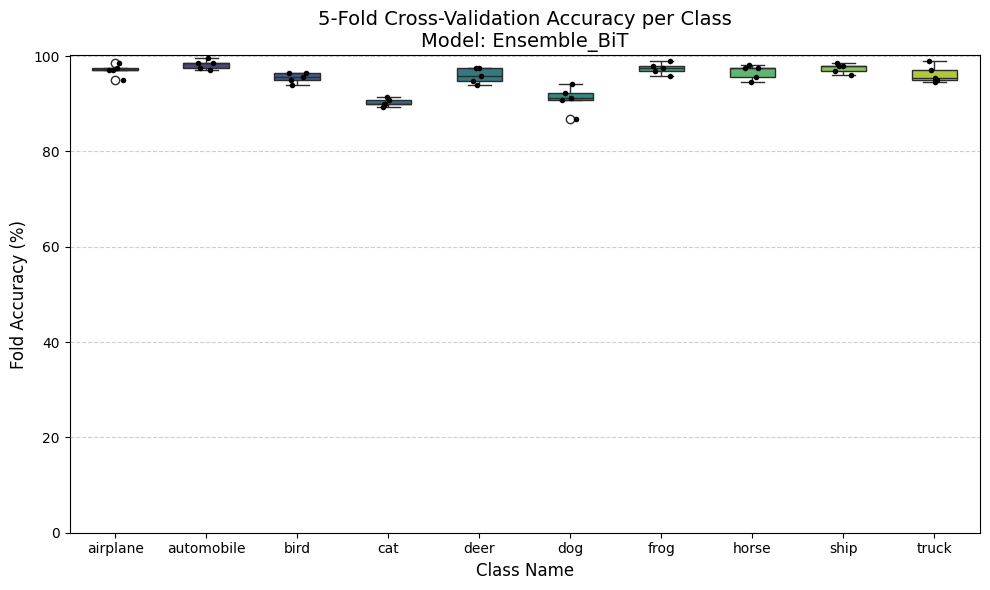

In [48]:
bit_config = {
    'model_name': 'resnetv2_50x1_bit.goog_in21k',
    'short_name': 'Ensemble_BiT',
    'batch_size': 512, 'total_steps': 1000,
    'optimizer': 'SGD', 'momentum': 0.9,
    'lr': 0.003, 'weight_decay': 0,
    'lr_decay_steps': [300, 600, 900], 'lr_decay_factor': 0.1,
    'train_transform': bit_train_transform,
    'val_transform': bit_val_transform
}

bit_final_results, bit_all_class_accs = run_production_5fold(
    bit_config, labels_df, img_dir, ImageDataset
)

/tmp/ipython-input-4204550877.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)



✅ Plot saved as: cv_results_Ensemble_BiT.png


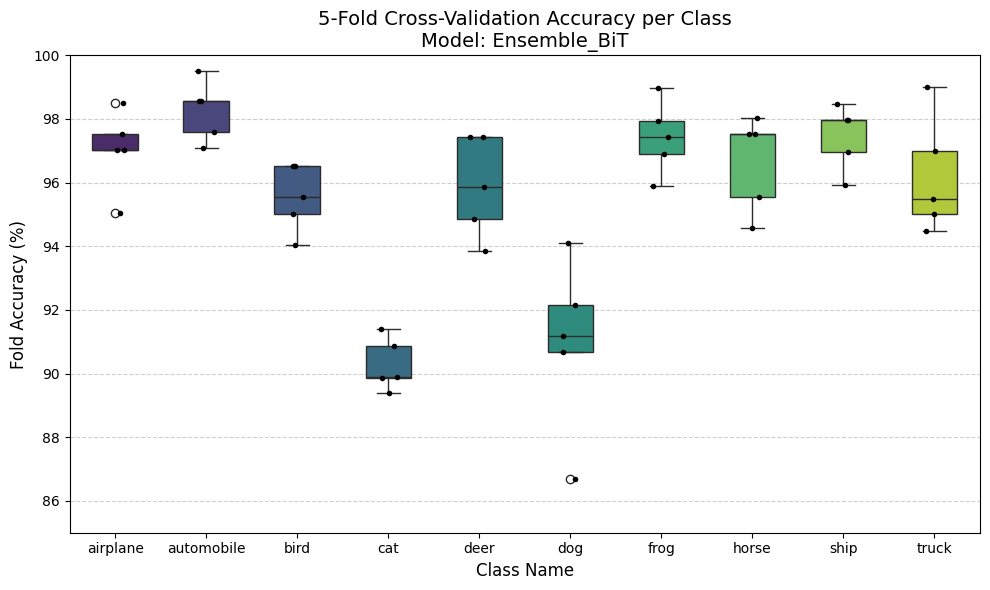

In [50]:
plot_cv_class_accuracies(
    bit_all_class_accs,
    bit_config['short_name']
)

#### Save Weights

In [53]:
import shutil
import os
from google.colab import drive

drive.mount('/content/drive')

source_pattern = "Ensemble_BiT_*.pth"
dest_folder = "/content/drive/MyDrive/ECSE 551/"

files_to_copy = glob.glob(source_pattern)

print(f"Found {len(files_to_copy)} models to copy...")

for file_path in files_to_copy:
    filename = os.path.basename(file_path)

    new_filename = f"CNN_{filename}"

    dest_path = os.path.join(dest_folder, new_filename)

    shutil.copy(file_path, dest_path)
    print(f"Copied: {filename} -> {dest_path}")

print("\nAll transfers complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5 models to copy...
Copied: Ensemble_BiT_Fold0_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNN_Ensemble_BiT_Fold0_seed42.pth
Copied: Ensemble_BiT_Fold2_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNN_Ensemble_BiT_Fold2_seed42.pth
Copied: Ensemble_BiT_Fold1_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNN_Ensemble_BiT_Fold1_seed42.pth
Copied: Ensemble_BiT_Fold3_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNN_Ensemble_BiT_Fold3_seed42.pth
Copied: Ensemble_BiT_Fold4_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNN_Ensemble_BiT_Fold4_seed42.pth

All transfers complete!


### ViT


STARTING 5-FOLD TRAINING FOR: swin_hf_cifar10
Config: Ensemble_Swin

--- Fold 1/5 ---

Training swin_hf_cifar10 | Seed 42
LR: 5e-05 | Batch: 64
--> Using AdamW (LR: 5e-05, WD: 0.03)


Training: 100%|██████████| 125/125 [00:24<00:00,  5.04it/s, loss=0.751, acc=75.6, step=125]


Step 125/500 | Train: 75.60% | Val: 92.85%


Training: 100%|██████████| 125/125 [00:24<00:00,  5.06it/s, loss=0.291, acc=90.3, step=250]


Step 250/500 | Train: 90.35% | Val: 94.10%


...

Step 375/500 | Train: 92.62% | Val: 94.85%


Training: 100%|██████████| 125/125 [00:24<00:00,  5.06it/s, loss=0.173, acc=94.2, step=500]


Step 500/500 | Train: 94.24% | Val: 95.30%
Loading best model from Ensemble_Swin_Fold4_seed42.pth...
--> Fold 5 Finished. Best Acc: 95.30%
--> Saved as: Ensemble_Swin_Fold4_seed42.pth

################################################################################
FINAL PER-CLASS CV RESULTS (swin_hf_cifar10)
################################################################################
Overall Mean Accuracy: 95.6600% ± 0.2223%

Class      | Mean Acc   | Std Dev   
-----------------------------------
airplane   | 96.1386% | ±2.7899%
automobile | 97.3913% | ±0.6553%
bird       | 94.9392% | ±1.2372%
cat        | 92.2074% | ±2.1302%
deer       | 95.0727% | ±1.6065%
dog        | 91.7579% | ±1.3588%
frog       | 97.4311% | ±0.5618%
horse      | 95.5616% | ±1.1678%
ship       | 98.1684% | ±0.6114%
truck      | 97.9925% | ±0.7769%




/tmp/ipython-input-1176567933.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)



✅ Plot saved as: cv_results_Ensemble_Swin.png


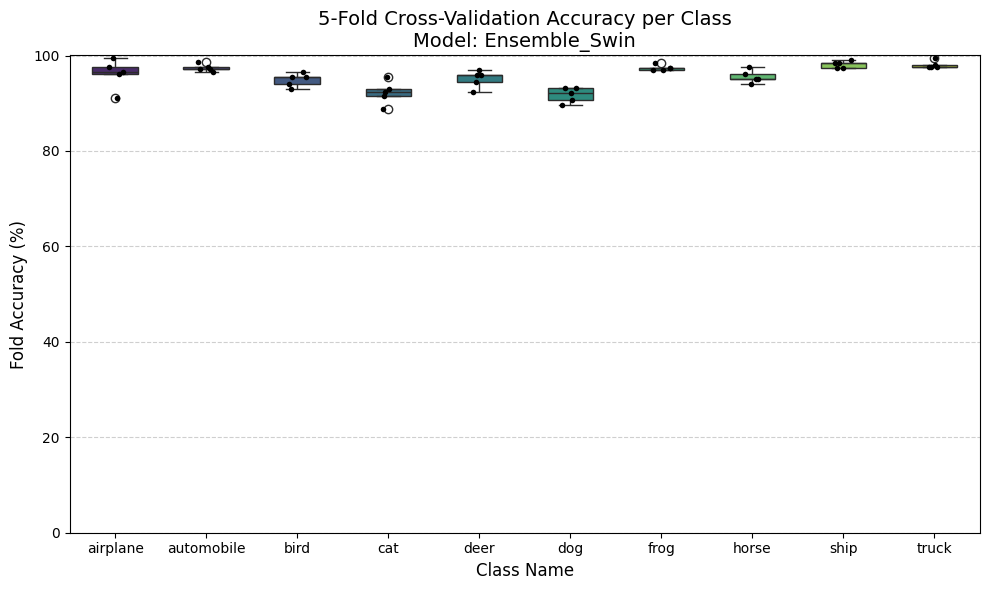

In [45]:
# Define Transforms (224x224 for Swin) recreated them here so as to not call previous HPO helper
swin_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25)
])

swin_val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

swin_config = {
    'model_name': 'swin_hf_cifar10',
    'hf_checkpoint': 'nielsr/swin-tiny-patch4-window7-224-finetuned-cifar10',
    'short_name': 'Ensemble_Swin',
    'batch_size': 64,
    'total_steps': 500,
    'optimizer': 'AdamW',
    'label_smoothing': 0.1,
    'lr': 5e-5,
    'weight_decay': 0.03,
    'drop_path_rate': 0.1,
    'img_size': 224,
    'use_cifar10_init': True,
    'train_transform': swin_train_tf,
    'val_transform': swin_val_tf
}

run_production_5fold(swin_config, labels_df, img_dir, ImageDataset)

swin_final_results, swin_all_class_accs = run_production_5fold(
    swin_config, labels_df, img_dir, ImageDataset
)

plot_cv_class_accuracies(
    swin_all_class_accs,
    swin_config['short_name']
)

/tmp/ipython-input-4204550877.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)



✅ Plot saved as: cv_results_Ensemble_Swin.png


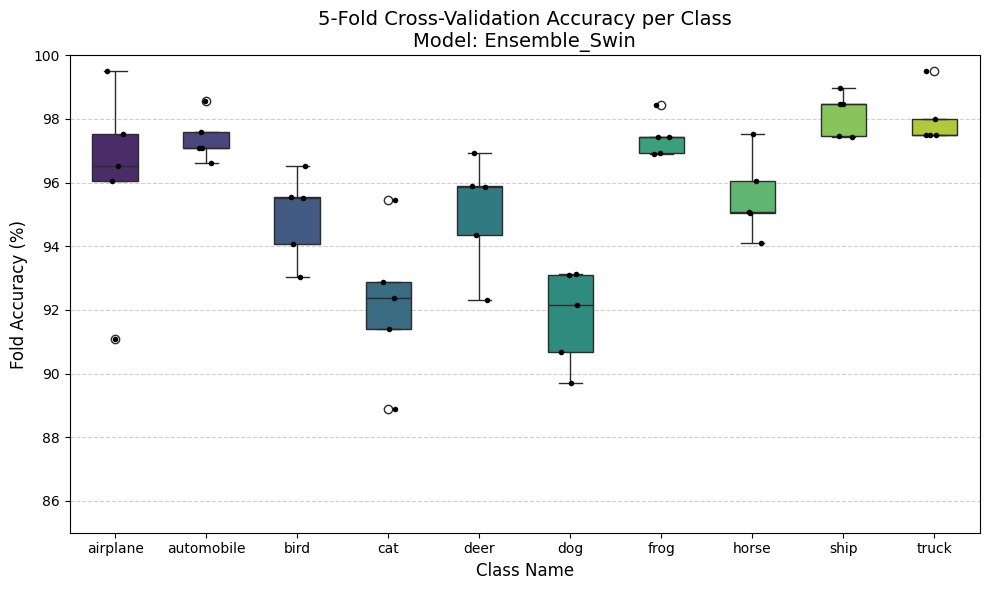

In [51]:
plot_cv_class_accuracies(
    swin_all_class_accs,
    swin_config['short_name']
)

#### Save Weights

In [54]:
import shutil
import os
from google.colab import drive

drive.mount('/content/drive')

source_pattern = "Ensemble_Swin_*.pth"
dest_folder = "/content/drive/MyDrive/ECSE 551/"

files_to_copy = glob.glob(source_pattern)

print(f"Found {len(files_to_copy)} models to copy...")

for file_path in files_to_copy:
    filename = os.path.basename(file_path)

    new_filename = f"ViT_{filename}"

    dest_path = os.path.join(dest_folder, new_filename)

    shutil.copy(file_path, dest_path)
    print(f"Copied: {filename} -> {dest_path}")

print("\nAll transfers complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5 models to copy...
Copied: Ensemble_Swin_Fold0_seed42.pth -> /content/drive/MyDrive/ECSE 551/ViT_Ensemble_Swin_Fold0_seed42.pth
Copied: Ensemble_Swin_Fold2_seed42.pth -> /content/drive/MyDrive/ECSE 551/ViT_Ensemble_Swin_Fold2_seed42.pth
Copied: Ensemble_Swin_Fold3_seed42.pth -> /content/drive/MyDrive/ECSE 551/ViT_Ensemble_Swin_Fold3_seed42.pth
Copied: Ensemble_Swin_Fold4_seed42.pth -> /content/drive/MyDrive/ECSE 551/ViT_Ensemble_Swin_Fold4_seed42.pth
Copied: Ensemble_Swin_Fold1_seed42.pth -> /content/drive/MyDrive/ECSE 551/ViT_Ensemble_Swin_Fold1_seed42.pth

All transfers complete!


### ConvNextNet


STARTING 5-FOLD TRAINING FOR: convnext_tiny.fb_in22k
Config: Ensemble_CNX

--- Fold 1/5 ---

Training convnext_tiny.fb_in22k | Seed 42
LR: 5e-05 | Batch: 64
--> Using AdamW (LR: 5e-05, WD: 0.01)


Training: 100%|██████████| 125/125 [00:26<00:00,  4.72it/s, loss=1.12, acc=69.6, step=125]


Step 125/1000 | Train: 69.61% | Val: 94.65%


Training: 100%|██████████| 125/125 [00:26<00:00,  4.72it/s, loss=0.348, acc=92.4, step=250]


Step 250/1000 | Train: 92.39% | Val: 94.85%


...

Step 875/1000 | Train: 98.11% | Val: 97.20%


Training: 100%|██████████| 125/125 [00:26<00:00,  4.72it/s, loss=0.0635, acc=98.3, step=1000]


Step 1000/1000 | Train: 98.30% | Val: 97.05%
Loading best model from Ensemble_CNX_Fold4_seed42.pth...
--> Fold 5 Finished. Best Acc: 97.20%
--> Saved as: Ensemble_CNX_Fold4_seed42.pth

################################################################################
FINAL PER-CLASS CV RESULTS (convnext_tiny.fb_in22k)
################################################################################
Overall Mean Accuracy: 97.2500% ± 0.3130%

Class      | Mean Acc   | Std Dev   
-----------------------------------
airplane   | 97.4257% | ±1.3060%
automobile | 98.5507% | ±0.8084%
bird       | 97.5174% | ±1.3361%
cat        | 92.1058% | ±1.6185%
deer       | 97.5311% | ±2.4285%
dog        | 95.6810% | ±0.5817%
frog       | 98.5620% | ±0.5975%
horse      | 98.3232% | ±1.7238%
ship       | 98.1721% | ±1.3841%
truck      | 98.5960% | ±1.1592%




/tmp/ipython-input-1176567933.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)



✅ Plot saved as: cv_results_Ensemble_CNX.png


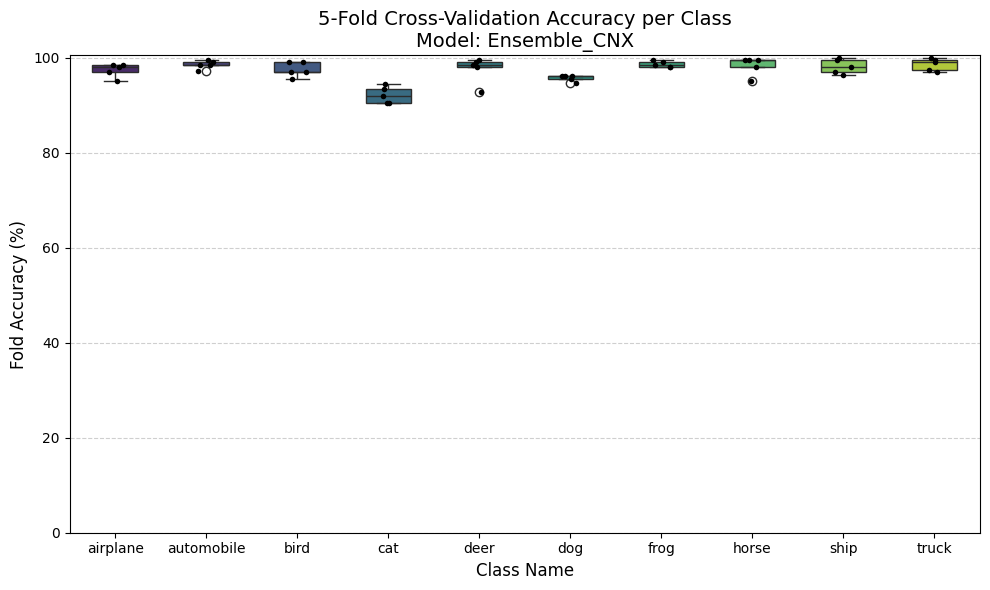

In [47]:
cnx_config = {
    'model_name': 'convnext_tiny.fb_in22k',
    'short_name': 'Ensemble_CNX', # Will become Ensemble_CNX_Fold0, Fold1...
    'batch_size': 64,
    'total_steps': 1000,
    'optimizer': 'AdamW',
    'label_smoothing': 0.1,
    'lr': 5e-5,              # HPO Winner
    'weight_decay': 0.01,    # HPO Winner
    'drop_path_rate': 0.1,   # HPO Winner
    'train_transform': cnx_train_transform,
    'val_transform': cnx_val_transform
}

cnx_final_results, cnx_all_class_accs = run_production_5fold(
    cnx_config, labels_df, img_dir, ImageDataset
)

/tmp/ipython-input-4204550877.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Accuracy (%)', data=df_melt, palette='viridis', width=0.5)



✅ Plot saved as: cv_results_Ensemble_CNX.png


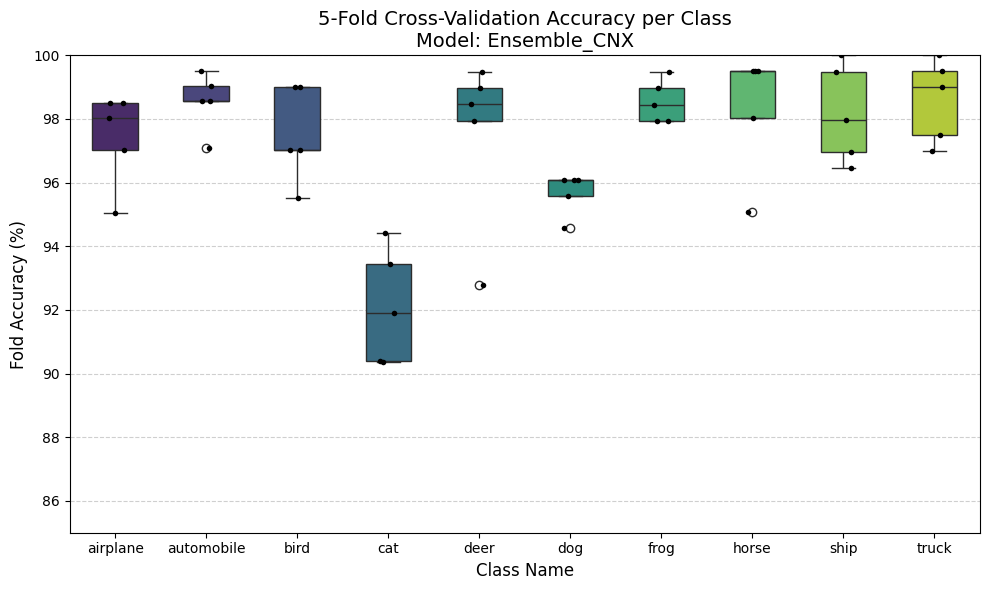

In [52]:
plot_cv_class_accuracies(
    cnx_all_class_accs,
    cnx_config['short_name']
)

#### Save Weights

In [55]:
import shutil
import os
from google.colab import drive

drive.mount('/content/drive')

source_pattern = "Ensemble_CNX_*.pth"
dest_folder = "/content/drive/MyDrive/ECSE 551/"

files_to_copy = glob.glob(source_pattern)

print(f"Found {len(files_to_copy)} models to copy...")

for file_path in files_to_copy:
    filename = os.path.basename(file_path)

    new_filename = f"CNX_{filename}"

    dest_path = os.path.join(dest_folder, new_filename)

    shutil.copy(file_path, dest_path)
    print(f"Copied: {filename} -> {dest_path}")

print("\nAll transfers complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5 models to copy...
Copied: Ensemble_CNX_Fold3_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNX_Ensemble_CNX_Fold3_seed42.pth
Copied: Ensemble_CNX_Fold0_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNX_Ensemble_CNX_Fold0_seed42.pth
Copied: Ensemble_CNX_Fold1_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNX_Ensemble_CNX_Fold1_seed42.pth
Copied: Ensemble_CNX_Fold2_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNX_Ensemble_CNX_Fold2_seed42.pth
Copied: Ensemble_CNX_Fold4_seed42.pth -> /content/drive/MyDrive/ECSE 551/CNX_Ensemble_CNX_Fold4_seed42.pth

All transfers complete!


# Inference

## Setup

In [18]:
train_df, val_df = train_test_split(labels_df, test_size=0.1,stratify=labels_df['label'])
# Doing this to ensure 100% similarity w test --> PREVENTING LABEL MISSMATCH
classes = sorted(train_df['label'].unique().tolist())
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}

EXPECTED_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
if classes != EXPECTED_CLASSES:
  raise Exception(f"Expected Classes Mismatch {classes} and {EXPECTED_CLASSES}")

print(f"Class mapping: {idx_to_class}")

test_img_dir='kaggle_challenge/test'
test_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

Class mapping: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


In [19]:
# 1. Create Dataset Class + DataFrame for files in test folder
file_list = sorted([f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
test_df = pd.DataFrame({'id': file_list}) # 'id' becomes col 0

print(test_df)

print(f"Found {len(test_df)} test images.")
if len(test_df) != 2000:
    raise Exception(f"Expected 2000 test images, but found {len(test_df)}.")

test_dataset = ImageDataset(
    df=test_df,
    img_dir=test_img_dir,
    transform=test_transform,
    is_test=True
)

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

             id
0     00000.png
1     00001.png
2     00002.png
3     00003.png
4     00004.png
...         ...
1995  01995.png
1996  01996.png
1997  01997.png
1998  01998.png
1999  01999.png

[2000 rows x 1 columns]
Found 2000 test images.


In [20]:
from google.colab import drive
drive.mount('/content/drive')

import glob, shutil, os

drive_folder = "/content/drive/MyDrive/ECSE 551/" # This is the variable to change to for saved weights path in drive
local_folder = "/content/models/"

os.makedirs(local_folder, exist_ok=True)

model_files = glob.glob(os.path.join(drive_folder, "*.pth"))

print("Found models:")
for f in model_files:
    print(" -", os.path.basename(f))

for f in model_files:
    shutil.copy(f, local_folder)

print("\nCopied to:", local_folder)

Mounted at /content/drive
Found models:
 - CNN_Ensemble_BiT_Fold3_seed42.pth
 - CNN_Ensemble_BiT_Fold2_seed42.pth
 - CNN_Ensemble_BiT_Fold4_seed42.pth
 - CNN_Ensemble_BiT_Fold1_seed42.pth
 - CNN_Ensemble_BiT_Fold0_seed42.pth
 - ViT_Ensemble_Swin_Fold4_seed42.pth
 - ViT_Ensemble_Swin_Fold0_seed42.pth
 - ViT_Ensemble_Swin_Fold3_seed42.pth
 - ViT_Ensemble_Swin_Fold1_seed42.pth
 - ViT_Ensemble_Swin_Fold2_seed42.pth
 - CNX_Ensemble_CNX_Fold3_seed42.pth
 - CNX_Ensemble_CNX_Fold1_seed42.pth
 - CNX_Ensemble_CNX_Fold4_seed42.pth
 - CNX_Ensemble_CNX_Fold0_seed42.pth
 - CNX_Ensemble_CNX_Fold2_seed42.pth

Copied to: /content/models/


In [21]:
model_files = glob.glob('models/*.pth')
if not model_files:
    print("No model files found! Check your directory.")
else:
    print(f"Found {len(model_files)} models: {model_files}")

Found 15 models: ['models/ViT_Ensemble_Swin_Fold4_seed42.pth', 'models/CNN_Ensemble_BiT_Fold1_seed42.pth', 'models/CNN_Ensemble_BiT_Fold4_seed42.pth', 'models/ViT_Ensemble_Swin_Fold3_seed42.pth', 'models/CNX_Ensemble_CNX_Fold3_seed42.pth', 'models/CNX_Ensemble_CNX_Fold1_seed42.pth', 'models/CNX_Ensemble_CNX_Fold0_seed42.pth', 'models/ViT_Ensemble_Swin_Fold0_seed42.pth', 'models/CNX_Ensemble_CNX_Fold2_seed42.pth', 'models/CNN_Ensemble_BiT_Fold0_seed42.pth', 'models/ViT_Ensemble_Swin_Fold1_seed42.pth', 'models/ViT_Ensemble_Swin_Fold2_seed42.pth', 'models/CNX_Ensemble_CNX_Fold4_seed42.pth', 'models/CNN_Ensemble_BiT_Fold2_seed42.pth', 'models/CNN_Ensemble_BiT_Fold3_seed42.pth']


## TTA

In [22]:
def get_10_crop_tta_BiT():
    """
    Standard 10-crop TTA for BiT-M models trained with Resize(160)->RandomCrop(128)

    Returns 10 transforms: 5 spatial crops × 2 flips
    """
    tta_transforms = []

    # Define 5 crop positions from 160x160 -> 128x128
    crop_positions = [
        (16, 16, 128, 128),  # center crop
        (0, 0, 128, 128),     # top-left
        (0, 32, 128, 128),    # top-right
        (32, 0, 128, 128),    # bottom-left
        (32, 32, 128, 128),   # bottom-right
    ]

    for top, left, height, width in crop_positions:
        for flip in [False, True]:
            tta_transforms.append(
                transforms.Compose([
                    transforms.Resize(160),
                    transforms.Lambda(lambda img, t=top, l=left, h=height, w=width:
                                    transforms.functional.crop(img, t, l, h, w)),
                    transforms.Lambda(lambda img, f=flip:
                                    transforms.functional.hflip(img) if f else img),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
                ])
            )

    return tta_transforms

In [23]:
def get_cnx_tta(num_translations=8):
    """
    TTA for ConvNeXt trained with RandomAffine translations
    Returns translations × 2 flips augmented views
    """
    tta_transforms = []

    # Define translation offsets (as fraction of image size)
    # translate=(0.1, 0.1) means ±10% shift during training
    if num_translations == 1:
        translations = [(0, 0)]  # center only
    elif num_translations == 4:
        # Center + 4 cardinal directions
        translations = [
            (0, 0),      # center
            (0, -0.08),  # up
            (0, 0.08),   # down
            (-0.08, 0),  # left
            (0.08, 0),   # right
        ]
    elif num_translations == 8:
        # Center + 8 directions (cardinal + diagonal)
        translations = [
            (0, 0),           # center
            (0, -0.08),       # up
            (0, 0.08),        # down
            (-0.08, 0),       # left
            (0.08, 0),        # right
            (-0.08, -0.08),   # top-left
            (0.08, -0.08),    # top-right
            (-0.08, 0.08),    # bottom-left
            (0.08, 0.08),     # bottom-right
        ]
    else:
        raise ValueError(f"num_translations must be 1, 4, or 8, got {num_translations}")

    for tx, ty in translations:
        for flip in [False, True]:
            tta_transforms.append(
                transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.Lambda(lambda img, tx=tx, ty=ty:
                                    transforms.functional.affine(
                                        img, angle=0,
                                        translate=(tx * 224, ty * 224),
                                        scale=1.0, shear=0
                                    )),
                    transforms.Lambda(lambda img, f=flip:
                                    transforms.functional.hflip(img) if f else img),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                       std=[0.229, 0.224, 0.225])
                ])
            )

    return tta_transforms

In [24]:
def get_swin_tta():
    """
    TTA for Swin Transformer trained with RandomCrop(224, padding=4)

    Padding=4 creates a 232×232 image, then crops 224×224
    We sample 5 deterministic crop positions + 2 flips = 10 views

    Returns 10 transforms: 5 spatial crops × 2 flips
    """
    tta_transforms = []

    # RandomCrop(224, padding=4) pads 224→232, then crops 224
    # We have 8 pixels of wiggle room (232-224=8)
    # Sample 5 crops: center + 4 corners

    # Crop positions (top, left, height, width) from 232×232 → 224×224
    crop_positions = [
        (4, 4, 224, 224),    # center (4px margin on all sides)
        (0, 0, 224, 224),    # top-left
        (0, 8, 224, 224),    # top-right (shift 8px right)
        (8, 0, 224, 224),    # bottom-left (shift 8px down)
        (8, 8, 224, 224),    # bottom-right
    ]

    for top, left, height, width in crop_positions:
        for flip in [False, True]:
            tta_transforms.append(
                transforms.Compose([
                    transforms.Resize((224, 224)),
                    # Pad by 4 pixels (same as training)
                    transforms.Pad(4, fill=0, padding_mode='constant'),  # 224→232
                    # Crop to 224×224 at specific position
                    transforms.Lambda(lambda img, t=top, l=left, h=height, w=width:
                                    transforms.functional.crop(img, t, l, h, w)),
                    transforms.Lambda(lambda img, f=flip:
                                    transforms.functional.hflip(img) if f else img),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                       std=[0.229, 0.224, 0.225])
                ])
            )

    return tta_transforms

## Inference (per-model averaging)

In [ ]:
all_model_probs = []
test_ids = []

print(f"{'='*60}")
print(f"STARTING ENSEMBLE INFERENCE (15 Models with Architecture-Specific TTA)")
print(f"{'='*60}")

for model_idx, model_path in enumerate(model_files):
    filename = os.path.basename(model_path)
    print(f"\n[{model_idx+1}/{len(model_files)}] Processing: {filename}")

    # --- A. Dynamic Model Loading & TTA Selection ---
    # We check the filename string to decide which logic to use

    if "CNX" in filename:
        print("   -> Architecture: ConvNeXt Tiny")
        # Load Architecture
        model = timm.create_model(
            'convnext_tiny.fb_in22k',
            pretrained=False,
            num_classes=10,
            drop_path_rate=0 # No drop path needed for inference
        )
        # Get Specific TTA (16 views)
        tta_transforms = get_cnx_tta(num_translations=8)
        print(f"   -> TTA Strategy: 16 Views (8 shifts * 2 flips)")

    elif "BiT" in filename:
        print("   -> Architecture: BiT-M ResNetV2")
        model = timm.create_model(
            'resnetv2_50x1_bit.goog_in21k',
            pretrained=False,
            num_classes=10
        )
        # Get Specific TTA (10 views)
        tta_transforms = get_10_crop_tta_BiT()
        print(f"   -> TTA Strategy: 10 Views (5 crops * 2 flips)")

    elif "Swin" in filename:
        print("   -> Architecture: Swin Transformer")
        # Note: Need to use the HF wrapper we defined earlier
        # We can pass None for checkpoint since we load state_dict right after
        model = HFtoTimm(
            checkpoint='nielsr/swin-tiny-patch4-window7-224-finetuned-cifar10',
            num_classes=10
        )
        # Get Specific TTA (10 views)
        tta_transforms = get_swin_tta()
        print(f"   -> TTA Strategy: 10 Views (5 crops * 2 flips)")

    else:
        raise ValueError(f"Unknown architecture in filename: {filename}")

    # --- B. Load Weights ---
    # Ensure device mapping is correct
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    model = send_to_gpu(model)
    model.eval()

    # --- C. TTA Inference Loop ---
    # This specific model's predictions across all its TTA views
    # Shape will be: [Num_TTA_Views, Num_Test_Images, Num_Classes]
    model_view_probs = []

    for i, transform in enumerate(tta_transforms):
        # Create temp dataset/loader for this specific view
        current_dataset = ImageDataset(
            df=test_df,
            img_dir=test_img_dir,
            transform=transform,
            is_test=True
        )
        # Large batch size for inference is fine
        current_loader = DataLoader(current_dataset, batch_size=256, shuffle=False, num_workers=2)

        crop_preds = []
        current_ids_temp = [] # Just to verify order matches

        with torch.no_grad():
            for images, img_names in current_loader:
                images = send_to_gpu(images)

                # Forward pass
                outputs = model(images)

                # Apply Softmax to get probabilities
                probs = F.softmax(outputs, dim=1)
                crop_preds.append(probs.cpu())

                if model_idx == 0 and i == 0:
                    test_ids.extend(img_names)

        # Concatenate batches
        full_crop_preds = torch.cat(crop_preds)
        model_view_probs.append(full_crop_preds)

    # --- D. Average TTA Views for THIS Model ---
    # This ensures a ConvNeXt with 16 views counts as "1 Model" just like a Swin with 10 views --> Total logit averaging is still over 15
    avg_single_model_prob = torch.stack(model_view_probs).mean(dim=0)

    # Add to global ensemble list
    all_model_probs.append(avg_single_model_prob)

    # Cleanup to save RAM
    del model, checkpoint
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"Ensemble Inference Complete.")
print(f"Total Models Aggregated: {len(all_model_probs)}")

## Inference Total Avg

In [ ]:
# 1. Stack to shape (15, 2000, 10)
ensemble_tensor = torch.stack(all_model_probs)

# 2. Define Weights corresponding to the order of your file list
# (We assign weights based on the architecture name in the file path)
weights = []
for f in model_files:
    if "CNX" in f:
        weights.append(1.2)  # ConvNeXt gets 20% more vote
    elif "BiT" in f:
        weights.append(1.0)
    elif "Swin" in f:
        weights.append(1.0)

# Turn list into a tensor shape (15, 1, 1) for broadcasting
weight_tensor = torch.tensor(weights).view(-1, 1, 1)

# 3. Compute Weighted Mean
# Sum(Prob * Weight) / Sum(Weights)
avg_probs = (ensemble_tensor * weight_tensor).sum(dim=0) / weight_tensor.sum()

# Soft Voting (confidence voting)
# Tensor: (num_models, num_samples, num_classes) -> Mean (avg over models) -> (num_samples, num_classes)
avg_probs = torch.stack(all_model_probs).mean(dim=0)

# Get final predicted classes from avged model confidences
pred_indices = torch.argmax(avg_probs, dim=1).numpy()

# Map indices back to Class Names (if required by Kaggle)
final_labels = [idx_to_class[idx] for idx in pred_indices]

# Create Submission DataFrame
submission = pd.DataFrame({
    'id': test_ids,      # Filename from the loader
    'label': final_labels # Predicted Class
})
submission = submission.sort_values(by='id') # To match sorted sample sub

# Save
submission.to_csv('submission.csv', index=False)
print("Successfully Saved submission.csv")
print(submission.head())

## Sanity

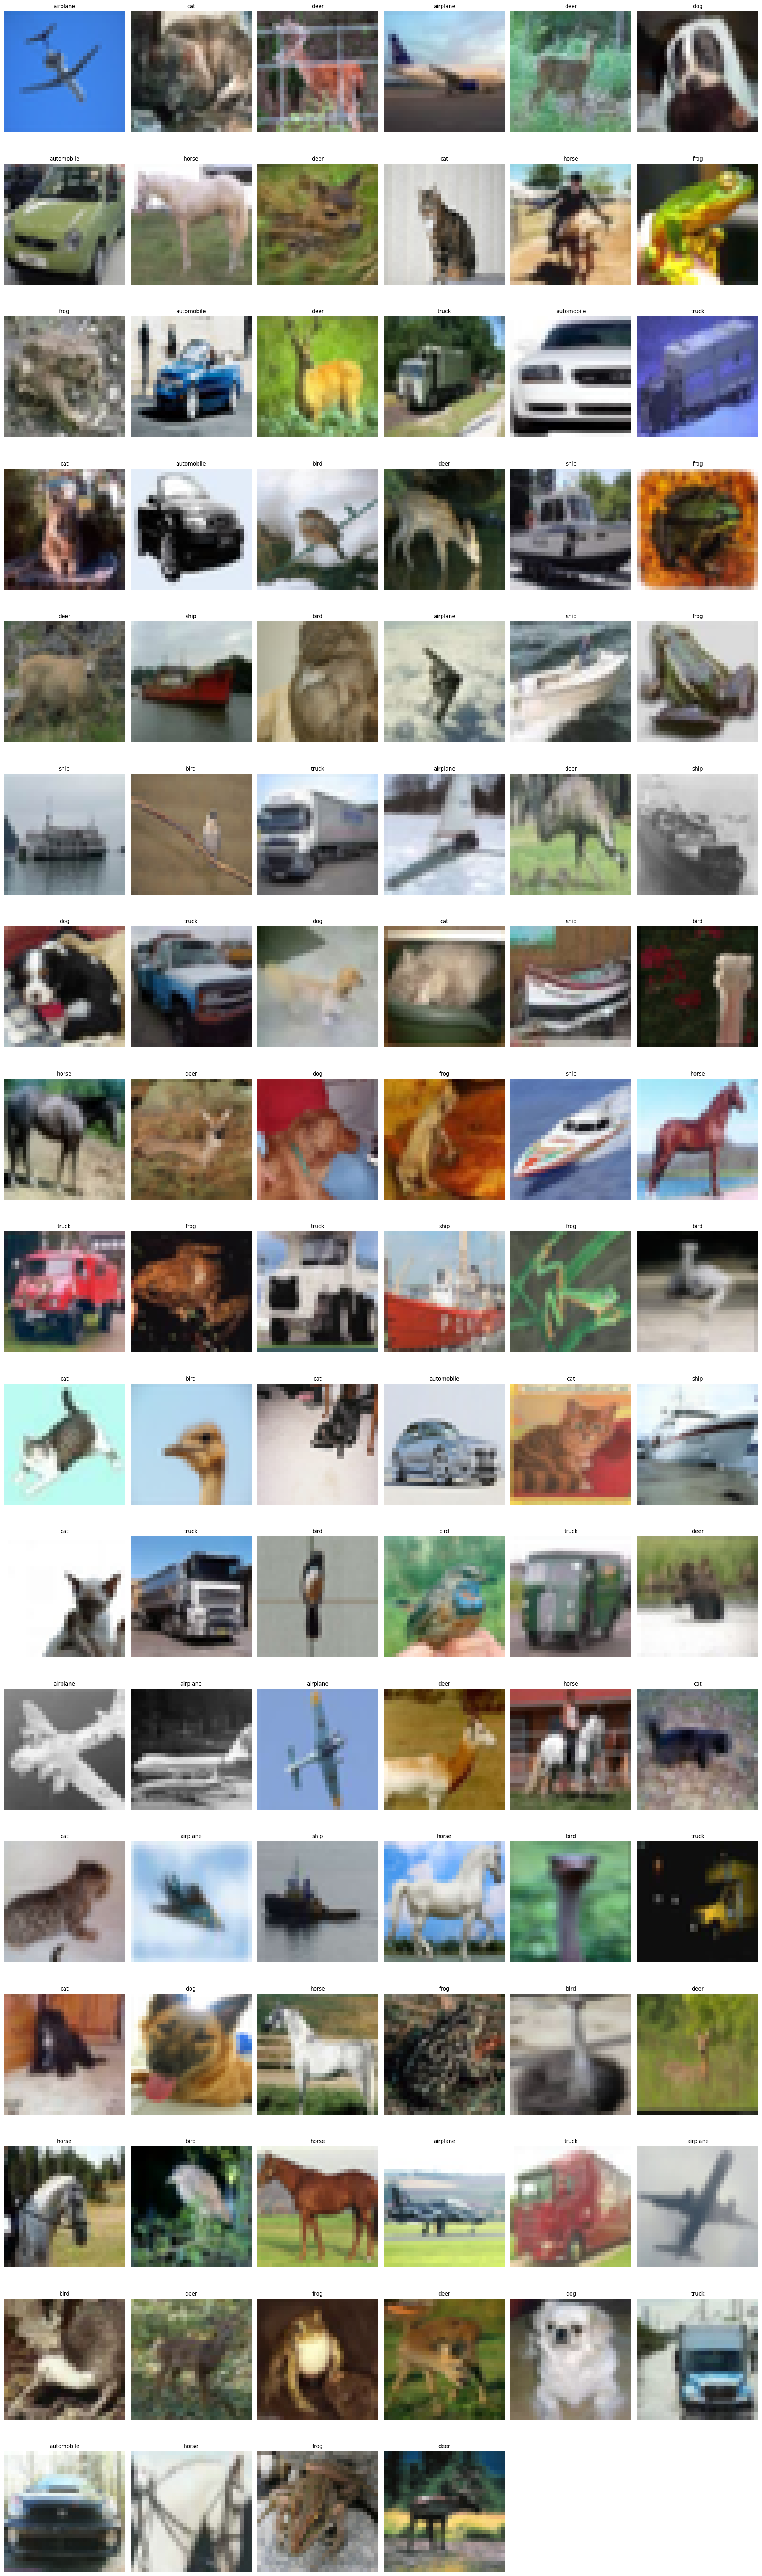

In [ ]:
import math
import matplotlib.pyplot as plt

# Settings
NUM_TO_SHOW = 100  # Change this to 50 or 100 if you want a huge grid
COLS = 6
ROWS = math.ceil(NUM_TO_SHOW / COLS)

# Grab a random sample of N images
sample_rows = submission.sample(NUM_TO_SHOW)

plt.figure(figsize=(20, 4 * ROWS)) # Dynamic height based on rows

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img_id = row['id']
    prediction = row['label']

    # Load image
    img_path = os.path.join(test_img_dir, img_id)
    image = Image.open(img_path)

    # Plot
    plt.subplot(ROWS, COLS, i + 1)
    plt.imshow(image)
    plt.title(f"{prediction}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()